# Hurricane Track Generation with LSTM-VAE

This notebook implements a Long Short-Term Memory Variational Autoencoder (LSTM-VAE) approach for generating realistic hurricane tracks. Unlike the previous VAE approach, this model explicitly accounts for the sequential nature of hurricane tracks, potentially generating more realistic and physically consistent hurricane trajectories.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.saving import register_keras_serializable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle
import re
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

# Enable memory growth on GPUs if available
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPU(s), memory growth enabled")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("No GPUs found, running on CPU")

TensorFlow version: 2.19.0
No GPUs found, running on CPU


## Data Preparation and Preprocessing

First, we need to parse the HURDAT2 data and prepare it for training our LSTM-VAE model. We'll reuse some functionality from the previous notebook but adapt it for sequence-based modeling.

In [2]:
# Hurricane data parsing class - slightly modified from previous implementation
class HurricaneDataHandler:
    def __init__(self, hurdat2_file):
        self.hurdat2_file = hurdat2_file
        self.hurdat_df = self.parse_hurdat2()
        
    def parse_hurdat2(self):
        """Parse the HURDAT2 format file into a pandas DataFrame"""
        with open(self.hurdat2_file, 'r') as f:
            file_content = f.read()
        
        lines = file_content.strip().split('\n')
        data = []
        current_header = None
        
        for line in lines:
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = line.split(',')
                basin_id = parts[0].strip()
                basin = basin_id[:2]
                cyclone_number = basin_id[2:4]
                year = basin_id[4:8]
                name = parts[1].strip()
                num_entries = int(parts[2].strip())
                current_header = {
                    'basin': basin,
                    'cyclone_number': cyclone_number,
                    'year': year,
                    'full_id': basin_id,
                    'name': name,
                    'num_entries': num_entries
                }
            else:
                if current_header:
                    parts = line.split(',')
                    date_str = parts[0].strip()
                    time_str = parts[1].strip()
                    year = int(date_str[0:4])
                    month = int(date_str[4:6])
                    day = int(date_str[6:8])
                    hour = int(time_str[0:2]) if time_str else 0
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                    record_id = parts[2].strip()
                    status = parts[3].strip()
                    lat_str = parts[4].strip()
                    lon_str = parts[5].strip()
                    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                    max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                    min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                    
                    # Parse wind radii if available (34kt, 50kt, 64kt)
                    ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                    se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                    sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                    nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                    ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                    se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                    sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                    nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                    ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                    se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                    sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                    nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                    rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                    
                    data.append({
                        'basin': current_header['basin'],
                        'cyclone_number': current_header['cyclone_number'],
                        'full_id': current_header['full_id'],
                        'storm_name': current_header['name'],
                        'year': year,
                        'month': month,
                        'day': day,
                        'hour': hour,
                        'minute': minute,
                        'record_id': record_id,
                        'status': status,
                        'latitude': lat,
                        'longitude': lon,
                        'max_wind': max_wind,
                        'min_pressure': min_pressure,
                        'ne_34kt_radius': ne_34kt,
                        'se_34kt_radius': se_34kt,
                        'sw_34kt_radius': sw_34kt,
                        'nw_34kt_radius': nw_34kt,
                        'ne_50kt_radius': ne_50kt,
                        'se_50kt_radius': se_50kt,
                        'sw_50kt_radius': sw_50kt,
                        'nw_50kt_radius': nw_50kt,
                        'ne_64kt_radius': ne_64kt,
                        'se_64kt_radius': se_64kt,
                        'sw_64kt_radius': sw_64kt,
                        'nw_64kt_radius': nw_64kt,
                        'radius_max_wind': rmw
                    })
        
        df = pd.DataFrame(data)
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        return df
    
    def prepare_training_data(self, min_wind_speed=50, min_sequence_length=5, region_filter=True):
        """
        Extract hurricane sequences suitable for LSTM-VAE training.
        Returns hurricane tracks as sequences suitable for LSTM training.
        """
        df = self.hurdat_df
        
        # Filter for hurricanes with sufficient wind speed
        strong_hurricanes = df[df['max_wind'] >= min_wind_speed]
        
        # Optionally filter by region (e.g., Atlantic hurricanes that might affect US East Coast)
        if region_filter:
            region_filter = (strong_hurricanes['latitude'] >= 10) & \
                            (strong_hurricanes['latitude'] <= 45) & \
                            (strong_hurricanes['longitude'] >= -100) & \
                            (strong_hurricanes['longitude'] <= -50)
            strong_hurricanes = strong_hurricanes[region_filter]
        
        # Handle missing values for all features
        strong_hurricanes = strong_hurricanes.dropna(subset=['latitude', 'longitude', 'max_wind'])
        strong_hurricanes = strong_hurricanes.fillna({
            'min_pressure': strong_hurricanes['min_pressure'].mean(),
            'ne_34kt_radius': 0, 'se_34kt_radius': 0, 
            'sw_34kt_radius': 0, 'nw_34kt_radius': 0,
            'ne_50kt_radius': 0, 'se_50kt_radius': 0,
            'sw_50kt_radius': 0, 'nw_50kt_radius': 0,
            'ne_64kt_radius': 0, 'se_64kt_radius': 0,
            'sw_64kt_radius': 0, 'nw_64kt_radius': 0,
            'radius_max_wind': 0
        })
        
        # Group by storm ID to get individual hurricane tracks
        grouped = strong_hurricanes.groupby('full_id')
        
        # Define all features to use (same as VAE V1)
        features = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        
        # Create a list of hurricane sequences
        hurricane_sequences = []
        hurricane_ids = []
        
        for storm_id, group in grouped:
            if len(group) >= min_sequence_length:  # Only include hurricanes with enough data points
                # Sort by datetime to ensure proper sequence
                track = group.sort_values('datetime')
                
                # Extract all features
                features_arr = track[features].values
                hurricane_sequences.append(features_arr)
                hurricane_ids.append(storm_id)
        
        print(f"Found {len(hurricane_sequences)} hurricane tracks suitable for training")
        return hurricane_sequences, hurricane_ids
    
    def select_hurricane(self, storm_id):
        """Select a specific hurricane by its ID"""
        hurricane_data = self.hurdat_df[self.hurdat_df['full_id'] == storm_id]
        if not hurricane_data.empty:
            storm_name = hurricane_data['storm_name'].iloc[0]
            print(f"Selected Hurricane: {storm_id}, {storm_name}")
        return hurricane_data
    
    def plot_hurricane_tracks(self, hurricane_data, title='Hurricane Tracks'):
        """Plot hurricane tracks on a map"""
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)

        # Plot hurricane path
        plt.plot(hurricane_data['longitude'], hurricane_data['latitude'],
                '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

        # Color points by intensity
        scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                            c=hurricane_data['max_wind'], cmap='YlOrRd', 
                            transform=ccrs.PlateCarree())

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')

        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()

Found 808 hurricane tracks suitable for training
Selected Hurricane: AL182012, SANDY


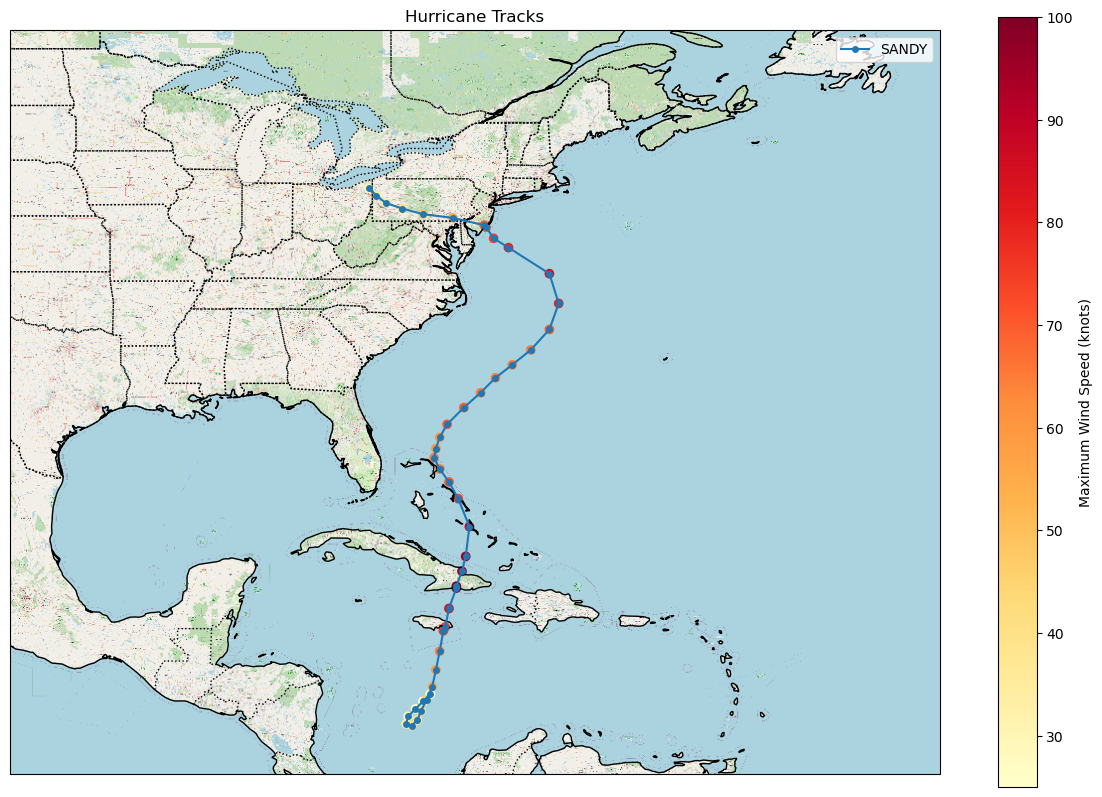

Sample sequence shape: (10, 17)
Sample sequence data (first 3 points):
[[ 25.7        -90.8         50.         976.64939173   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]
 [ 26.3        -90.4         50.         976.64939173   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]
 [ 27.         -90.          50.         976.64939173   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]]


In [3]:
# Load and prepare hurricane data
hurdat2_file = 'project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'
data_handler = HurricaneDataHandler(hurdat2_file)

# Prepare sequences for LSTM training
hurricane_sequences, hurricane_ids = data_handler.prepare_training_data(min_wind_speed=50, min_sequence_length=10)

# Example: View a single hurricane track
# sample_id = hurricane_ids[10]  # Choose a sample hurricane
sample_id = 'AL182012'
sample_hurricane = data_handler.select_hurricane(sample_id)
data_handler.plot_hurricane_tracks(sample_hurricane)

# Print sample sequence data
print(f"Sample sequence shape: {hurricane_sequences[10].shape}")
print("Sample sequence data (first 3 points):")
print(hurricane_sequences[10][:3])

## LSTM-VAE Model Implementation

Now we'll implement the LSTM-VAE model architecture. This will consist of:

1. An encoder with LSTM layers to process hurricane sequences
2. A latent space sampling mechanism
3. A decoder that generates hurricane sequences from the latent space

In [5]:
@register_keras_serializable(package="Custom", name="sampling")
def _sampling(args):
    """Reparameterization trick for sampling from latent space"""
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAELossLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        self.add_loss(tf.reduce_mean(kl_loss))
        return z_mean  # Return z_mean as a placeholder

class HurricaneLSTMVAE:
    def __init__(self, input_dim=17, latent_dim=32, sequence_length=None, lstm_units=64):
        """
        Initialize the LSTM-VAE model for hurricane track generation
        
        Parameters:
        -----------
        input_dim : int
            Dimension of input features at each time step
            (now 17 for all features)
        latent_dim : int
            Dimension of the latent space
        sequence_length : int or None
            Maximum sequence length (can be None for variable-length sequences)
        lstm_units : int
            Number of LSTM units in each layer
        """
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.scaler = MinMaxScaler()
        self.z_mean = None
        self.z_log_var = None
        self._build_model()
        
    def _reconstruction_loss_fn(self, y_true, y_pred):
        """
        Reconstruction loss for sequences (e.g., Mean Squared Error over all timesteps and features).
        """
        mse = tf.keras.losses.MeanSquaredError()
        return mse(y_true, y_pred)

    def _build_model(self):
        """Construct the LSTM-VAE model architecture"""
        # Define encoder
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name="encoder_input")
        
        # LSTM encoder layers
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="encoder_lstm_1")(encoder_inputs)
        x = layers.LSTM(self.lstm_units, name="encoder_lstm_2")(x)
        
        # Define latent space parameters
        self.z_mean = layers.Dense(self.latent_dim, name="z_mean")(x)
        self.z_log_var = layers.Dense(self.latent_dim, name="z_log_var")(x)
        
        # Sampling layer using reparameterization trick
        z = layers.Lambda(_sampling, name="z_sampling")([self.z_mean, self.z_log_var])
        
        # Add the custom KL loss layer
        _ = VAELossLayer()([self.z_mean, self.z_log_var])
        
        # Define encoder model
        self.encoder = keras.Model(encoder_inputs, [self.z_mean, self.z_log_var, z], name="encoder")
        print("Encoder model summary:")
        self.encoder.summary()
        
        # Define decoder
        latent_inputs = keras.Input(shape=(self.latent_dim,), name="decoder_latent_input")
        x = layers.RepeatVector(self.sequence_length, name="repeat_vector")(latent_inputs)
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="decoder_lstm_1")(x)
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="decoder_lstm_2")(x)
        decoder_outputs = layers.TimeDistributed(layers.Dense(self.input_dim), name="decoder_output_timedistributed")(x)
        
        # Define decoder model
        self.decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
        print("\nDecoder model summary:")
        self.decoder.summary()
        
        # Define VAE model
        outputs = self.decoder(z)
        self.vae = keras.Model(encoder_inputs, outputs, name="lstm_vae")
        self.vae.compile(optimizer='adam', loss=self._reconstruction_loss_fn)
        
    def preprocess_data(self, hurricane_sequences):
        """Preprocess hurricane sequences for LSTM training"""
        if self.sequence_length is None:
            self.sequence_length = max([len(seq) for seq in hurricane_sequences])
        
        padded_sequences = []
        for seq in hurricane_sequences:
            if len(seq) > self.sequence_length:
                padded_sequences.append(seq[:self.sequence_length])
            elif len(seq) < self.sequence_length:
                padding = np.zeros((self.sequence_length - len(seq), self.input_dim))
                padded_sequences.append(np.vstack([seq, padding]))
            else:
                padded_sequences.append(seq)
                
        padded_sequences = np.array(padded_sequences, dtype=np.float32)
        original_shape = padded_sequences.shape
        flattened = padded_sequences.reshape(-1, self.input_dim)
        scaled_flattened = self.scaler.fit_transform(flattened)
        scaled_sequences = scaled_flattened.reshape(original_shape)
        return scaled_sequences
        
    def train(self, hurricane_sequences, epochs=50, batch_size=32, validation_split=0.2):
        """Train the LSTM-VAE on hurricane sequences"""
        processed_sequences = self.preprocess_data(hurricane_sequences)
        history = self.vae.fit(
            processed_sequences, processed_sequences,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=10,
                    restore_best_weights=True
                )
            ]
        )
        return history
    
    def generate_hurricane(self, num_points=None, seed_hurricane_features=None, randomness=0.5):
        """Generate a synthetic hurricane track using the trained LSTM-VAE"""
        if num_points is None:
            num_points = self.sequence_length
            
        if seed_hurricane_features is not None:
            seed_data_scaled = self.preprocess_data([seed_hurricane_features])
            z_mean, z_log_var, _ = self.encoder.predict(seed_data_scaled)
            epsilon = np.random.normal(0, 1, size=z_mean.shape)
            latent_vector = z_mean + np.exp(0.5 * z_log_var) * epsilon * randomness
        else:
            latent_vector = np.random.normal(0, 1, size=(1, self.latent_dim))
        
        generated_track_scaled = self.decoder.predict(latent_vector)[0]
        generated_track = self.scaler.inverse_transform(generated_track_scaled)
        
        if num_points and num_points < len(generated_track):
            generated_track = generated_track[:num_points]
        
        # All features
        columns = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        track_df = pd.DataFrame(generated_track, columns=columns[:self.input_dim])
        start_date = datetime.now()
        track_df['datetime'] = [start_date + timedelta(hours=i*6) for i in range(len(track_df))]
        track_df['year'] = track_df['datetime'].dt.year
        track_df['month'] = track_df['datetime'].dt.month
        track_df['day'] = track_df['datetime'].dt.day
        track_df['hour'] = track_df['datetime'].dt.hour
        track_df['minute'] = 0
        track_df['status'] = 'HU'
        track_df['full_id'] = 'LSTM_SYN_' + start_date.strftime('%Y%m%d%H%M')
        track_df['storm_name'] = 'LSTM_Synthetic_' + start_date.strftime('%Y%m%d%H%M')
        
        # Post-process: round and clip as appropriate for each feature
        if 'max_wind' in track_df.columns:
            track_df['max_wind'] = track_df['max_wind'].round().astype(int)
            track_df['max_wind'] = np.clip(track_df['max_wind'], 20, 180)
        if 'min_pressure' in track_df.columns:
            track_df['min_pressure'] = track_df['min_pressure'].round().astype(int)
            track_df['min_pressure'] = np.clip(track_df['min_pressure'], 880, 1020)
        for col in [
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]:
            if col in track_df.columns:
                track_df[col] = track_df[col].round().astype(int)
                track_df[col] = np.clip(track_df[col], 0, 400)
        
        track_df = self.apply_geographic_constraints(track_df)
        return track_df
    
    def apply_geographic_constraints(self, track_df, max_latitude=47):
        """Apply geographic constraints to ensure realistic hurricane tracks"""
        df = track_df.copy()
        for i in range(1, len(df)):
            lat_diff = abs(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude'])
            lon_diff = abs(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude'])
            if lat_diff > 3 or lon_diff > 3:
                df.loc[i, 'latitude'] = df.loc[i-1, 'latitude'] + np.sign(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude']) * 1.5
                df.loc[i, 'longitude'] = df.loc[i-1, 'longitude'] + np.sign(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude']) * 1.5
        
        for i in range(len(df)):
            if df.loc[i, 'latitude'] > 30:
                weakening_factor = max(0.3, 1.0 - (df.loc[i, 'latitude'] - 30) / 25)
                df.loc[i, 'max_wind'] = int(df.loc[i, 'max_wind'] * weakening_factor)
                df.loc[i, 'min_pressure'] = min(1020, int(df.loc[i, 'min_pressure'] + (1 - weakening_factor) * 50))
            if df.loc[i, 'latitude'] > max_latitude:
                df.loc[i, 'status'] = 'EX'
        
        df['longitude'] = ((df['longitude'] + 180) % 360) - 180
        return df
    
    def save_model(self, filepath):
        """Save the trained LSTM-VAE models and scaler"""
        self.encoder.save(filepath + "_encoder.keras")
        self.decoder.save(filepath + "_decoder.keras")
        with open(filepath + "_scaler.pkl", 'wb') as f:
            pickle.dump(self.scaler, f)
        params = {
            'input_dim': self.input_dim,
            'latent_dim': self.latent_dim,
            'sequence_length': self.sequence_length,
            'lstm_units': self.lstm_units
        }
        with open(filepath + "_params.pkl", 'wb') as f:
            pickle.dump(params, f)
    
    def load_model(self, filepath):
        """Load trained LSTM-VAE models and scaler"""
        with open(filepath + "_params.pkl", 'rb') as f:
            params = pickle.load(f)
        self.input_dim = params['input_dim']
        self.latent_dim = params['latent_dim']
        self.sequence_length = params['sequence_length']
        self.lstm_units = params['lstm_units']
        with open(filepath + "_scaler.pkl", 'rb') as f:
            self.scaler = pickle.load(f)
        self.encoder = keras.models.load_model(filepath + "_encoder.keras", custom_objects={'_sampling': _sampling})
        self.decoder = keras.models.load_model(filepath + "_decoder.keras")
        
        # Rebuild the VAE model
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name="vae_input_loaded")
        z_mean, z_log_var, z = self.encoder(encoder_inputs)
        
        # Add KL divergence loss using the custom layer
        _ = VAELossLayer()([z_mean, z_log_var])
        
        reconstructed_outputs = self.decoder(z)
        self.vae = keras.Model(encoder_inputs, reconstructed_outputs, name="lstm_vae_loaded")
        self.vae.compile(optimizer='adam', loss=self._reconstruction_loss_fn)
        print("LSTM-VAE model loaded successfully.")

## Training and Using the LSTM-VAE

Now, let's instantiate the model, train it, generate synthetic hurricane tracks, and demonstrate saving/loading the model.

Using fixed sequence length: 75
Encoder model summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 75, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_1      │ (None, 75, 64)    │     20,992 │ encoder_input[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_2      │ (None, 64)        │     33,024 │ encoder_lstm_1[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling (Lambda) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,176 (227.25 KB)

 Trainable params: 58,176 (227.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_latent_input            │ (None, 32)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 75, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 75, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output_timedistributed  │ (None, 75, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,961 (230.32 KB)

 Trainable params: 58,961 (230.32 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM-VAE with 808 sequences...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0772 - val_loss: 0.0324
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0772 - val_loss: 0.0324
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0287 - val_loss: 0.0261
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0287 - val_loss: 0.0261
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0216 - val_loss: 0.0182
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0216 - val_loss: 0.0182
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0142 - val_loss: 0.0165
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0142 - val_loss: 0.0165
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0136 - val_loss: 0.0166
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0136 - val_loss: 0.0166
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0133 - val_loss: 0.0165
Epoch 7/50
21/21 ━━━━━━━

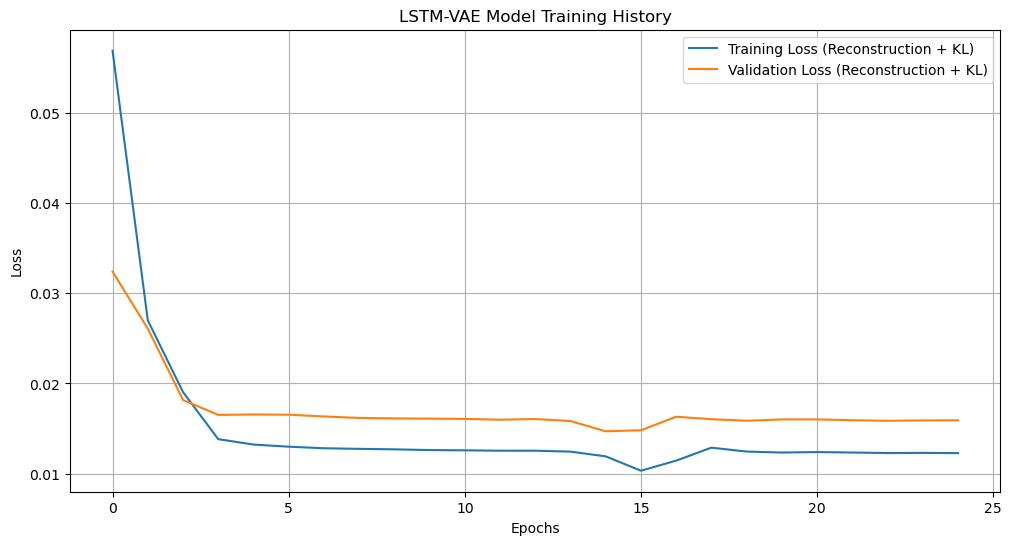


Model saved to prefix: hurricane_lstm_vae_model_v2
Encoder model summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 75, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_1      │ (None, 75, 64)    │     20,992 │ encoder_input[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_2      │ (None, 64)        │     33,024 │ encoder_lstm_1[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling (Lambda) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,176 (227.25 KB)

 Trainable params: 58,176 (227.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_latent_input            │ (None, 32)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 75, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 75, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output_timedistributed  │ (None, 75, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,961 (230.32 KB)

 Trainable params: 58,961 (230.32 KB)

 Non-trainable params: 0 (0.00 B)

LSTM-VAE model loaded successfully.
LSTM-VAE Model loaded successfully from prefix.

Generating a random synthetic hurricane track...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Generated Random Synthetic Track (first 5 points):
   latitude   longitude  max_wind  min_pressure  ne_34kt_radius  \
0  2.660621  -97.938248        20           880               4   
1  2.953644 -100.263092        20           880               3   
2  4.453644 -101.763092        20           880               3   
3  2.953644 -103.263092        20           880               4   
4  4.453644 -104.763092        20           880               6   

   se_34kt_radius  sw_34kt_radius  nw_34kt_radius  ne_50kt_radius  \
0               0              13               0               0   
1               0              13               3               0   
2               0              13               6               0   
3               0              10               9         

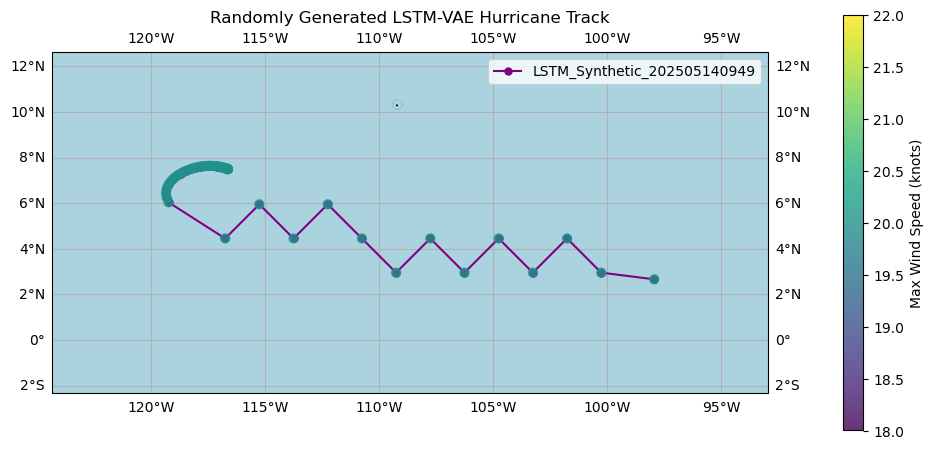

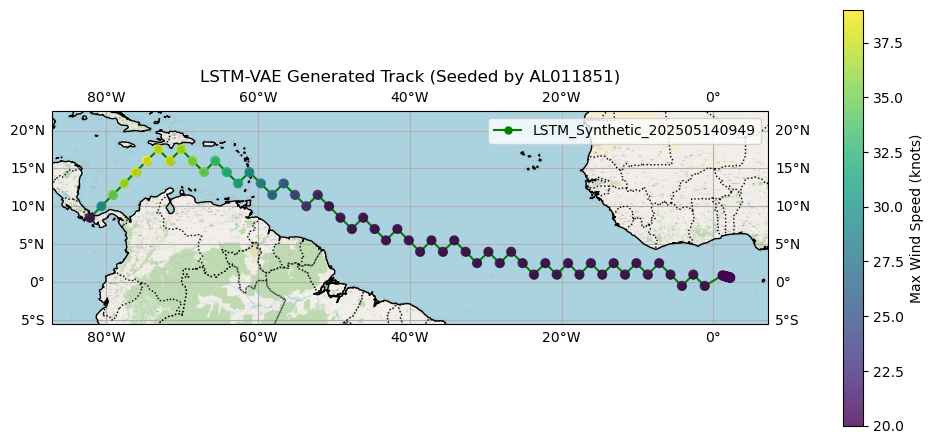

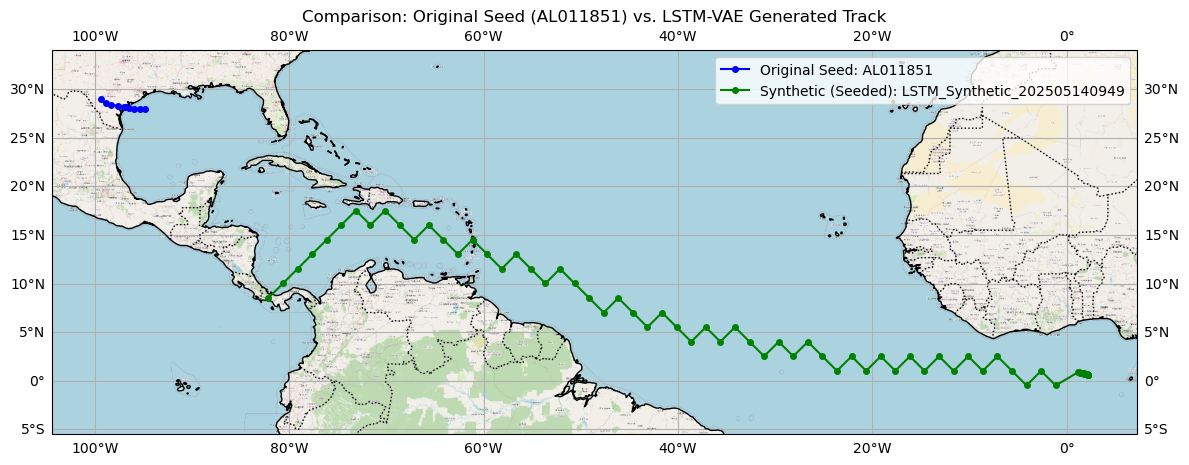

In [7]:
# --- Parameters ---
INPUT_DIM = 17  # Now using all features
LATENT_DIM = 32 # Dimensionality of the latent space
LSTM_UNITS = 64 # Number of units in LSTM layers
EPOCHS = 50     # Number of training epochs
BATCH_SIZE = 32 # Batch size for training

# Determine FIXED_SEQUENCE_LENGTH from the loaded hurricane_sequences
if not hurricane_sequences:
    print("Error: hurricane_sequences is not defined or empty. Please run the data preparation cells first.")
    FIXED_SEQUENCE_LENGTH = 50
else:
    FIXED_SEQUENCE_LENGTH = max(len(seq) for seq in hurricane_sequences)
    FIXED_SEQUENCE_LENGTH = min(FIXED_SEQUENCE_LENGTH, 75)
    print(f"Using fixed sequence length: {FIXED_SEQUENCE_LENGTH}")

# --- Initialize Model ---
lstm_vae = HurricaneLSTMVAE(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    sequence_length=FIXED_SEQUENCE_LENGTH,
    lstm_units=LSTM_UNITS
)

# The 'hurricane_sequences' variable should be available from Cell 5.
# The 'train' method of HurricaneLSTMVAE will handle preprocessing internally.
if 'hurricane_sequences' in locals() and hurricane_sequences:
    # --- Train Model ---
    print(f"\nTraining LSTM-VAE with {len(hurricane_sequences)} sequences...")
    # The train method calls preprocess_data internally.
    history = lstm_vae.train(
        hurricane_sequences, # Pass the raw sequences
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2
    )

    if history:
        # Plot training history
        plt.figure(figsize=(12, 6))
        plt.plot(history.history['loss'], label='Training Loss (Reconstruction + KL)')
        plt.plot(history.history['val_loss'], label='Validation Loss (Reconstruction + KL)')
        if 'kl_loss' in history.history: # KL loss as a metric
             plt.plot(history.history['kl_loss'], label='Training KL Loss (metric)')
        if 'val_kl_loss' in history.history:
             plt.plot(history.history['val_kl_loss'], label='Validation KL Loss (metric)')
        plt.title('LSTM-VAE Model Training History')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    # --- Save Model ---
    MODEL_SAVE_PATH = 'hurricane_lstm_vae_model_v2' # Using a new version name
    lstm_vae.save_model(MODEL_SAVE_PATH)
    print(f"\nModel saved to prefix: {MODEL_SAVE_PATH}")

    # --- Load Model (Example) ---
    # For loading, ensure parameters match the saved model, especially sequence_length.
    # The load_model method reads these from _params.pkl.
    loaded_lstm_vae = HurricaneLSTMVAE(
        input_dim=INPUT_DIM, # Provide initial params, load_model will overwrite from file
        latent_dim=LATENT_DIM,
        sequence_length=FIXED_SEQUENCE_LENGTH, # Crucial for model architecture before loading weights
        lstm_units=LSTM_UNITS
    )
    loaded_lstm_vae.load_model(MODEL_SAVE_PATH)
    print("LSTM-VAE Model loaded successfully from prefix.")

    # --- Generate Synthetic Hurricane Tracks ---
    
    # Option 1: Generate a completely random synthetic hurricane
    print("\nGenerating a random synthetic hurricane track...")
    random_synthetic_track = loaded_lstm_vae.generate_hurricane(
        num_points=FIXED_SEQUENCE_LENGTH, # Generate full sequence
        randomness=0.8 # Higher randomness for more diversity
    )
    print("Generated Random Synthetic Track (first 5 points):")
    print(random_synthetic_track.head())

    # Option 2: Generate using a seed hurricane
    # We'll use one of the sequences from our dataset as a seed.
    # The seed_hurricane_features should be a raw numpy array [timesteps, features].
    if hurricane_sequences:
        seed_index = 0 # Use the first hurricane sequence as a seed
        # Ensure seed_index is valid
        if seed_index < len(hurricane_sequences):
            seed_track_raw_features = hurricane_sequences[seed_index]
            original_seed_id = hurricane_ids[seed_index] # Get the ID for labeling
            print(f"\nGenerating a synthetic hurricane track seeded from: {original_seed_id}...")
            
            seeded_synthetic_track = loaded_lstm_vae.generate_hurricane(
                seed_hurricane_features=seed_track_raw_features,
                num_points=FIXED_SEQUENCE_LENGTH, # Generate full sequence
                randomness=0.3 # Lower randomness to stay closer to the seed
            )
            print("Generated Seeded Synthetic Track (first 5 points):")
            print(seeded_synthetic_track.head())

            # --- Visualize Generated Tracks ---
            def plot_hurricane_track_df(track_df, title="Hurricane Track", color='red', label_prefix=""):
                fig = plt.figure(figsize=(12, 9))
                ax = plt.axes(projection=ccrs.PlateCarree())
                ax.add_feature(cfeature.COASTLINE, zorder=3)
                ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
                ax.add_feature(cfeature.STATES, linestyle=':', zorder=3, alpha=0.7)
                
                # Define extent based on track data, with some padding
                min_lon, max_lon = track_df['longitude'].min(), track_df['longitude'].max()
                min_lat, max_lat = track_df['latitude'].min(), track_df['latitude'].max()
                padding = 5 # degrees
                ax.set_extent([min_lon - padding, max_lon + padding, 
                               min_lat - padding, max_lat + padding], crs=ccrs.PlateCarree())

                try:
                    # Add OpenStreetMap background tiles
                    osm_tiles = cimgt.OSM()
                    ax.add_image(osm_tiles, 7, zorder=1) # Adjust zoom level (e.g., 6 or 7)
                except Exception as e:
                    print(f"Warning: Could not load OSM tiles: {e}. Using basic map features.")
                    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', zorder=1)
                    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=1)

                # Plot hurricane path
                track_label = f"{label_prefix}{track_df['storm_name'].iloc[0]}" if 'storm_name' in track_df.columns else f"{label_prefix}Track"
                ax.plot(track_df['longitude'], track_df['latitude'],
                         '-o', color=color, markersize=5, transform=ccrs.Geodetic(), 
                         label=track_label, zorder=4)

                # Color points by intensity (max_wind) if available
                if 'max_wind' in track_df.columns:
                    sc = ax.scatter(track_df['longitude'], track_df['latitude'], 
                                    c=track_df['max_wind'], cmap='viridis', 
                                    transform=ccrs.Geodetic(), s=40, zorder=5, alpha=0.8)
                    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.08)
                    cbar.set_label('Max Wind Speed (knots)')
                
                ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=2)
                plt.title(title)
                plt.legend()
                plt.show()

            plot_hurricane_track_df(random_synthetic_track, title="Randomly Generated LSTM-VAE Hurricane Track", color='purple')
            plot_hurricane_track_df(seeded_synthetic_track, title=f"LSTM-VAE Generated Track (Seeded by {original_seed_id})", color='green')

            # For comparison, convert the original seed (raw features) to a DataFrame
            original_seed_df = pd.DataFrame(
                seed_track_raw_features,
                columns=[
                    'latitude', 'longitude', 'max_wind', 'min_pressure',
                    'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
                    'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
                    'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
                    'radius_max_wind'
                ]
            )
            # Fill in other details for plotting consistency if needed
            original_seed_df['storm_name'] = f"Original_{original_seed_id}"
            original_seed_df['datetime'] = [datetime.now() + timedelta(hours=i*6) for i in range(len(original_seed_df))]
            
            # Plot original seed and synthetic track together
            fig_comp = plt.figure(figsize=(14, 10))
            ax_comp = plt.axes(projection=ccrs.PlateCarree())
            ax_comp.add_feature(cfeature.COASTLINE, zorder=3)
            ax_comp.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
            
            # Combine extents
            all_lons = pd.concat([original_seed_df['longitude'], seeded_synthetic_track['longitude']])
            all_lats = pd.concat([original_seed_df['latitude'], seeded_synthetic_track['latitude']])
            ax_comp.set_extent([all_lons.min() - 5, all_lons.max() + 5, 
                                all_lats.min() - 5, all_lats.max() + 5], crs=ccrs.PlateCarree())
            try:
                osm_tiles_comp = cimgt.OSM()
                ax_comp.add_image(osm_tiles_comp, 6, zorder=1)
            except Exception as e:
                print(f"Warning: Could not load OSM tiles for comparison: {e}.")
                ax_comp.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
                ax_comp.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=1)

            ax_comp.plot(original_seed_df['longitude'], original_seed_df['latitude'],
                         '-o', color='blue', markersize=4, transform=ccrs.Geodetic(), 
                         label=f"Original Seed: {original_seed_id}", zorder=4)
            ax_comp.plot(seeded_synthetic_track['longitude'], seeded_synthetic_track['latitude'],
                         '-o', color='green', markersize=4, transform=ccrs.Geodetic(), 
                         label=f"Synthetic (Seeded): {seeded_synthetic_track['storm_name'].iloc[0]}", zorder=5)
            
            ax_comp.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=2)
            plt.title(f"Comparison: Original Seed ({original_seed_id}) vs. LSTM-VAE Generated Track")
            plt.legend()
            plt.show()
        else:
            print(f"Seed index {seed_index} is out of bounds for hurricane_sequences (length {len(hurricane_sequences)}). Skipping seeded generation.")
    else:
        print("No hurricane_sequences available to use as a seed. Skipping seeded generation.")
else:
    print("Skipping LSTM-VAE training and generation as 'hurricane_sequences' is not available or empty.")